In [1]:
import sys
sys.path.append('/Users/anyaphillips/Desktop/harvard/research/via_binaries/scripts')
sys.path.append('/Users/anyaphillips/Downloads/software/viamock/')

import functions as paf
import petar
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('vedant')
%matplotlib inline
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from astropy.table import Table
from scipy.stats import binned_statistic_2d

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm


from tqdm import tqdm

import pandas as pd

from astropy.table import Table
import astropy.constants as const
import astropy.units as u
from scipy.stats import binned_statistic
from matplotlib.gridspec import GridSpecFromSubplotSpec
""
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap

import viamock

lm_colors, hm_colors, simcolors = paf.define_simcolors()
time_cmap = paf.define_time_cmap()

Duplicate key in file PosixPath('/Users/anyaphillips/.matplotlib/stylelib/vedant.mplstyle'), line 46 ('lines.linewidth : 3')

Bad key hist.type in file /Users/anyaphillips/.matplotlib/stylelib/vedant.mplstyle, line 45 ('hist.type : step')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.8/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution
/opt/anaconda3/envs/viamock/lib/python3.10/site-packages/matplotlib_inline/config.py:74: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


# getting to know viamock

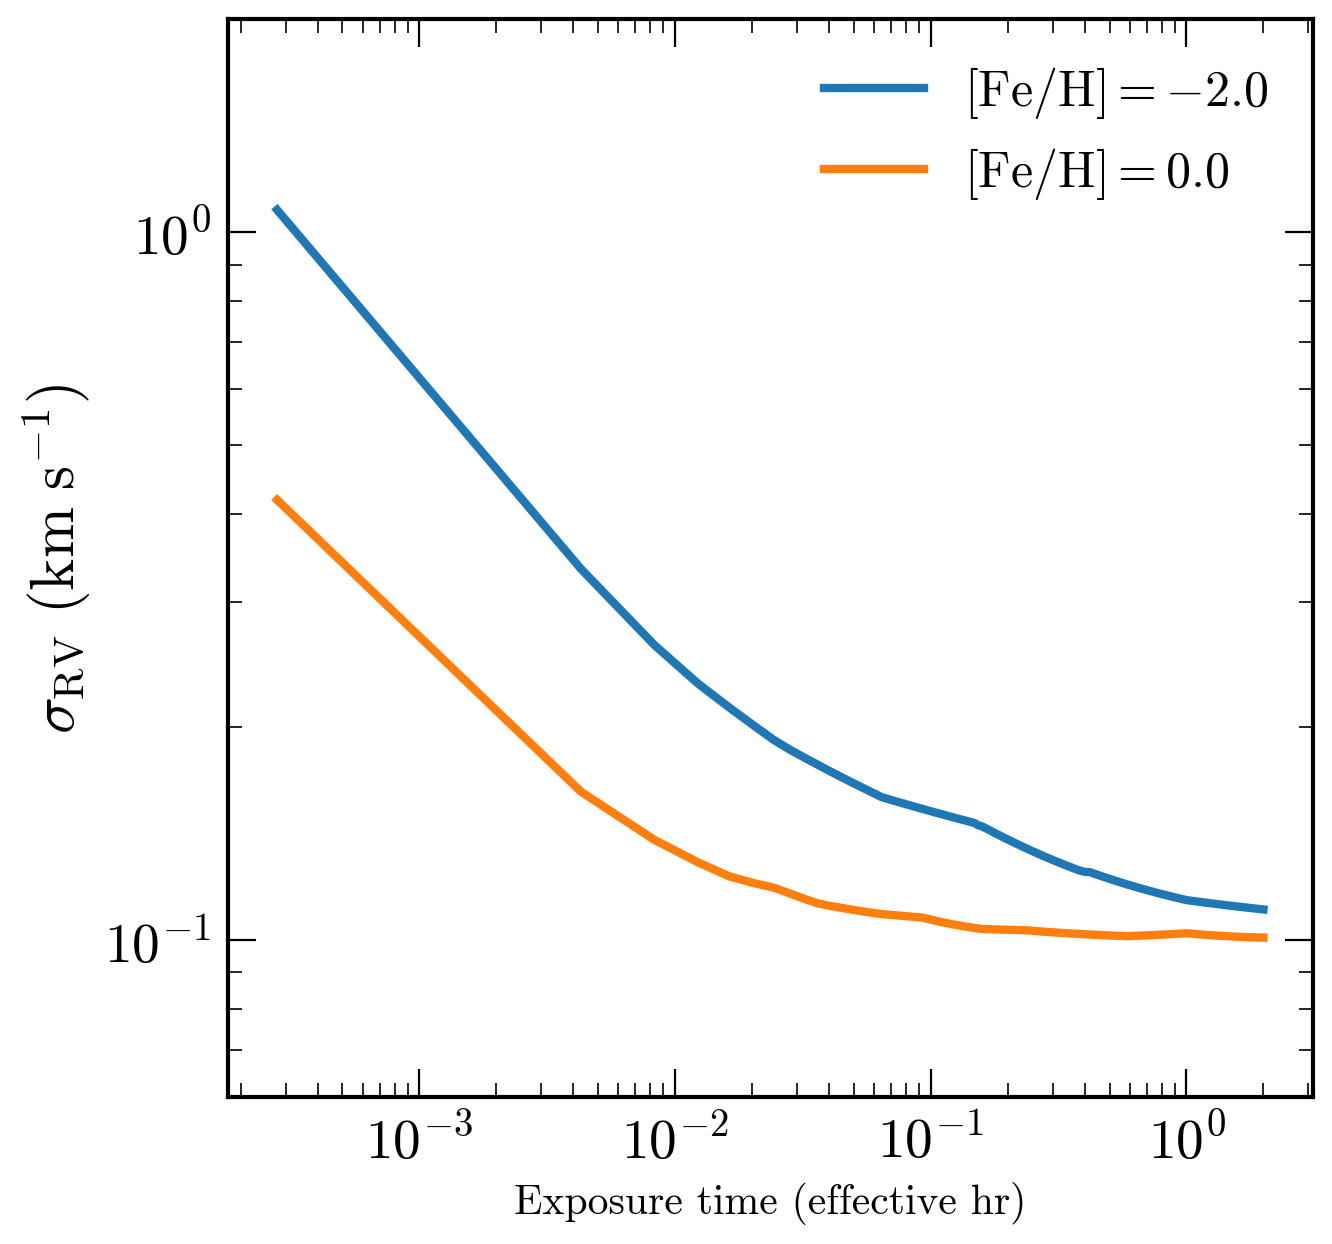

In [2]:
# test run with viamock

### deciding that each stream star gets 2 ehrs 
exptimes = np.linspace(1*u.s.to(u.hr), 2, 500)
ervs = []
ervs_highz = []
for ehr in exptimes:
    erv = viamock.errors.get_viaspec_errors(G=17, feh=-2.0, logteff = np.log10(4700), exptime_ehr=ehr)
    erv_highz = viamock.errors.get_viaspec_errors(G=17, feh=0.0, logteff = np.log10(4700), exptime_ehr=ehr)
    ervs.append(erv[0])
    ervs_highz.append(erv_highz[0])

ervs = np.array(ervs)

fig, ax = plt.subplots()
ax.plot(exptimes, ervs, label=r'[Fe/H]$=-2.0$')
ax.plot(exptimes, ervs_highz, label=r'[Fe/H]$=0.0$')
ax.set_xlabel('Exposure time (effective hr)', fontsize=15)
ax.legend(loc='upper right')
ax.set_ylabel(r'$\sigma_{\rm RV}~(\rm km~s^{-1})$')
ax.set_yscale("log")
ax.set_ylim(0.06, 2)
ax.set_xscale("log")

# loading binary sample

In [52]:
### load binaries: 

binaries = pd.read_csv('UPDATED_detection_fractions_dense/cosmic_example_IBC.csv')
N = len(binaries)
print(N)

15000


In [53]:
### stack orbital params. want v0 (km/s), K (km/s), w, phi0, e, P (day)
rng = np.random.default_rng(seed=42)

m1 = binaries['mass_1'].values * u.Msun
m2 = binaries['mass_2'].values * u.Msun
q = m2/m1
mtot = m1+m2
P = binaries['porb'].values * u.day # days
logP = np.log10(P.to(u.day).value)
a = paf.calc_a(P, mtot)

e = binaries['ecc'].values
i = paf.draw_inclinations(N, rng=rng)
K = paf.calc_K(mtot, m2, a, e, P, i)
v0 = np.zeros(N)*(u.km/u.s)

w = rng.uniform(low=0, high=2*np.pi, size=N)
phi0 = rng.uniform(low=0, high=1, size=N)

params = np.array([
    v0.to(u.km/u.s).value,
    K.to(u.km/u.s).value, 
    w,
    phi0,
    e,
    P.to(u.day).value
]).T

# results from `detection_fractions_dense`

* this is using a fixed RV uncertainty of 0.1 km/s; also no noise has been injected into the data. 

In [4]:
### first, use viamock to determine noise level for 3 visits. 
exposure_time = 2.0/3 ## 2 total effective hours divided between three visits
erv = viamock.errors.get_viaspec_errors(G=17, feh=-2.0, logteff=np.log10(4700), exptime_ehr=exposure_time)[0]
print(erv)

0.11823167210684976


In [33]:
### eventually, do Delta t_1 in 1-day increments, 
# delta t2 from like 1--360 days also in 1-day increments. 
# this will be the check on whether period aliasing is a problem or not


# institutional knowledge of what I ran in the slurm array. 
dt1_min, dt1_max, dt1_step = 1,150,1
dt1_vals  = np.arange(dt1_min, dt1_max+dt1_step, dt1_step) 

dt2_min, dt2_max, dt2_step = 1, 2*365, 1
dt2_vals = np.arange(dt2_min, dt2_max+dt2_step, dt2_step)

dfa = []

for k, dt1 in enumerate(dt1_vals, start=1):
    dfa_this_dt1 = np.loadtxt("UPDATED_detection_fractions_dense/ms_%i.txt"%k)
    dfa.append(dfa_this_dt1)
dfa = np.array(dfa)

/var/folders/q2/m18s57611677cjnvtmvry2v80000gn/T/ipykernel_33394/3540126076.py:25: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ob2 = ax.contour(X,Y,Z, levels=black_levels,


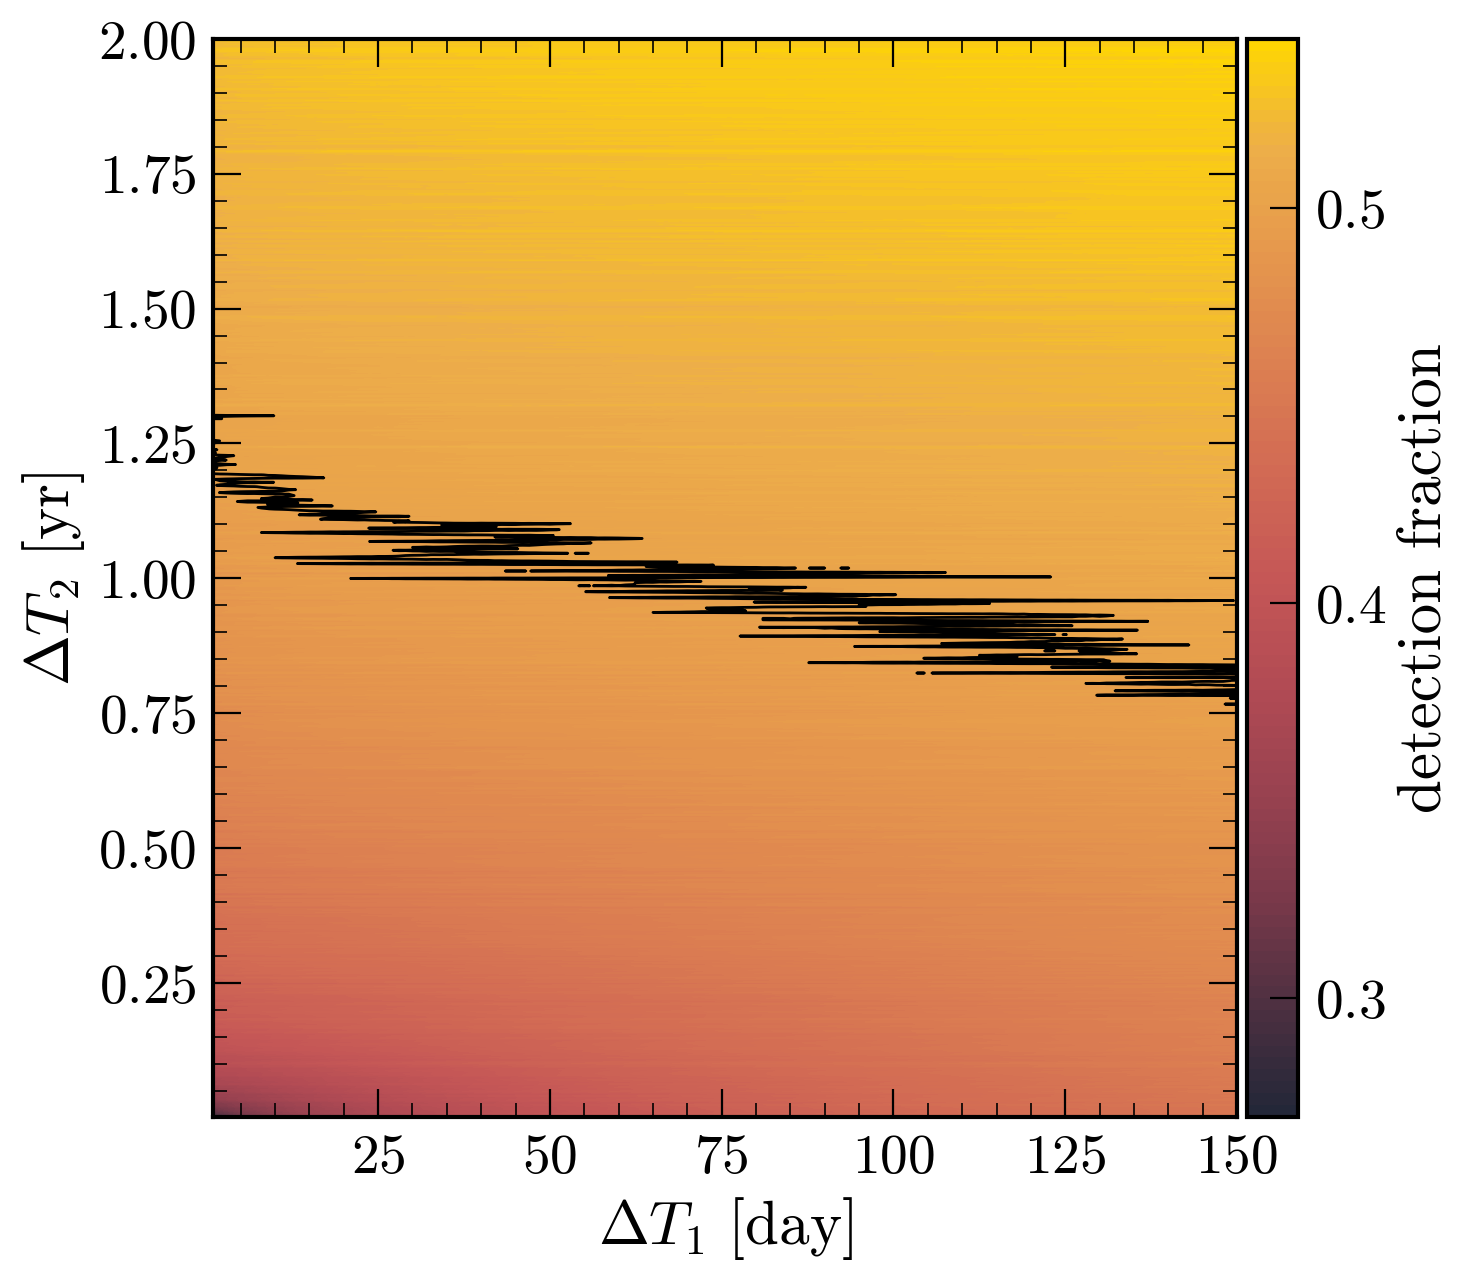

In [48]:
colors=["#212738","#4D3041","#79394A","#994250","#B24B54","#C55756","#D26A54","#DC8051","#E5974D","#EDAE49", "gold"]
# colors.reverse()
# colors = paf.define_simcolors()
df_cmap = LinearSegmentedColormap.from_list('df_cmap', colors)#[1]+colors[0])

X, Y = np.meshgrid(dt1_vals, dt2_vals)
Z = dfa.T

Y = Y/365
fig, ax = plt.subplots()
# ax.imshow(dfa, cmap=time_cmap)
ob = ax.contourf(X,Y, Z, cmap=df_cmap, levels=100)


ax.set_ylim(np.min(Y), np.max(Y))
ax.set_xlim(np.min(X), np.max(X))
ax.set_xlabel(r"$\Delta T_1~\rm [day]$")
ax.set_ylabel(r'$\Delta T_2~\rm [yr]$')
# ax.set_xscale('log')
# ax.set_yscale('log')


# black_levels = np.arange(0.2, 0.5, 0.002) ### <-- dense black contours to look more at aliasing
black_levels = np.array([0.5])#0.3, 0.7, 0.05)
ob2 = ax.contour(X,Y,Z, levels=black_levels,
           linestyle="solid", colors="k", linewidths=1)
# ax.clabel(ob2, ob2.levels,
#            fontsize=10)


divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar = fig.colorbar(ob, cax=cax, label=r"detection fraction")
cbar.set_ticks([0.3, 0.4, 0.5])
# cbar.set_ticks(black_levels[::5])

### add lines where dt2 is an integer multiple of dt1
# x = np.linspace(np.min(dt1_vals), np.max(dt1_vals), 2)
# n_vals = np.arange(1, 50, 1)
# for n in n_vals:
#     y = n*x
#     y = y/365
#     ax.plot(x,y, c='white', lw=1, ls=':')

# ax.set_xscale('log')
# ax.set_yscale('log')

In [ ]:
ƒ

# results from adding visits/compromising SNR. 

prelim, from science book -- what I take from this is that for stream stars (typically closer to G=20, [Fe/H]=-2) we're looking at a SNR of ~10 with 1 hour exposures, which translates maybe to like a few hundred m/s for RGB stars, and about a km/s for MSTO stars. 

In [49]:
def get_obstimes_from_logNormal_scatter(N, offset, survey_duration_days, nvisits, frac_scatter):
    ### logarithmically spaced samples
    t_means = np.logspace(np.log10(offset), np.log10(survey_duration_days+offset), nvisits) - offset # logarithmically spaced points   
    sigma = np.sqrt(np.log(1 + frac_scatter**2))
    mu_vals = np.log(t_means) - 0.5 * sigma**2

    base = np.repeat(0, N)
    DTs_per_visit = [] # loop through each mean and sample a lognormal distribution -- one DT per star out of N stars. 
    for mu in mu_vals:
        DT_list = rng.lognormal(mean=mu, sigma=sigma, size=N)
        DTs_per_visit.append(DT_list)
    
    deltaTs = np.vstack([base]+DTs_per_visit).T

    
    ### update deltaTs so that the survey duration is < 5 yr. **unf this is very slow for large nvisits. 
    bad = np.sum(deltaTs, axis=1)>survey_duration_days
    while np.any(bad):
        nbad = bad.sum()
        for i, mu in enumerate(mu_vals, start=1):
            deltaTs[bad, i] = rng.lognormal(mean=mu, sigma=sigma, size=nbad)
        bad = np.max(deltaTs, axis=1) > survey_duration_days

    # obstimes_all = np.cumsum(deltaTs, axis=1)
    obstimes_all=deltaTs
    return obstimes_all

# def get_obstime_list(N, DT_list):
#     """
#     given deterministic DTs, get obstimes. 
#     """
#     base = np.repeat(0, N)
#     gaps = [np.repeat(DT, N) for DT in DT_list]
#     deltaTs = np.vstack([base]+gaps).T
#     obstimes_all = np.cumsum(deltaTs, axis=1)
#     return obstimes_all


In [50]:
def get_detection_fraction(obstimes, exposure_time, magnitude, rng):
    erv = viamock.errors.get_viaspec_errors(G=magnitude, feh=-2.0, logteff=np.log10(4700), exptime_ehr=exposure_time)[0]
    rvs = paf.get_rvs(params, obstimes, verbose=False, add_noise=True, noise_level = erv, rng=rng)
    detected, deltavsys = paf.get_detections(
            erv, # km/s
            rvs,
            v0, 
            bool_arr='detet'
    )
    detection_fraction = len(v0[detected])/len(v0)
    return detection_fraction

In [55]:
### set random seed generator
rng = np.random.default_rng(42)

# global variables
max_exposuretime=2 # effective hours
survey_duration_days = 365*5
Gmags_list = np.arange(16,21,1)
nvisits_list = np.arange(2, 8, 1)# 11, 1)
offset=1

##################
print("case 1: vary N visits, 2-visit case is a 5 year baseline:")
dfs_case1 = []
for Gmag in tqdm(Gmags_list):
    dfs_this_gmag = []
    for nvisits in nvisits_list:
        obstimes = np.logspace(np.log10(offset), np.log10(survey_duration_days+offset), nvisits) - offset
        obstimes = np.vstack([obstimes]*N) # ?   
        exposure_time_per_visit = max_exposuretime/nvisits
        detection_fraction = get_detection_fraction(obstimes, exposure_time=exposure_time_per_visit, magnitude=Gmag, rng=rng)
        dfs_this_gmag.append(detection_fraction)
    dfs_case1.append(dfs_this_gmag)


##################
print("case 2: the 2-visit case is a shorter baseline")
first_2_visits = np.array(np.logspace(np.log10(offset), np.log10(survey_duration_days+offset), 3)-1)[:2]
dfs_case2 = []
for Gmag in tqdm(Gmags_list):
    obstimes = np.vstack([first_2_visits]*N)
    exposure_time_per_visit = max_exposuretime/2
    detection_fraction = get_detection_fraction(obstimes, exposure_time=exposure_time_per_visit, magnitude=Gmag, rng=rng)
    dfs_case2.append(detection_fraction)

##################
print("case 3: 2 visit cadence is a 5 year baseline but total exposure time keeps increasing")
dfs_case3 = []
for Gmag in tqdm(Gmags_list):
    dfs_this_gmag = []
    for nvisits in nvisits_list:
        obstimes = np.logspace(np.log10(offset), np.log10(survey_duration_days+offset), nvisits)-offset
        obstimes = np.vstack([obstimes] * N)
        detection_fraction = get_detection_fraction(obstimes, exposure_time = 0.5, # efective hours
                                                    magnitude=Gmag, rng=rng)
        dfs_this_gmag.append(detection_fraction)
    dfs_case3.append(dfs_this_gmag)

case 1: vary N visits, 2-visit case is a 5 year baseline:


100%|██████████| 5/5 [00:21<00:00,  4.37s/it]


case 2: the 2-visit case is a shorter baseline


100%|██████████| 5/5 [00:03<00:00,  1.29it/s]


case 3: 2 visit cadence is a 5 year baseline but total exposure time keeps increasing


100%|██████████| 5/5 [00:21<00:00,  4.33s/it]


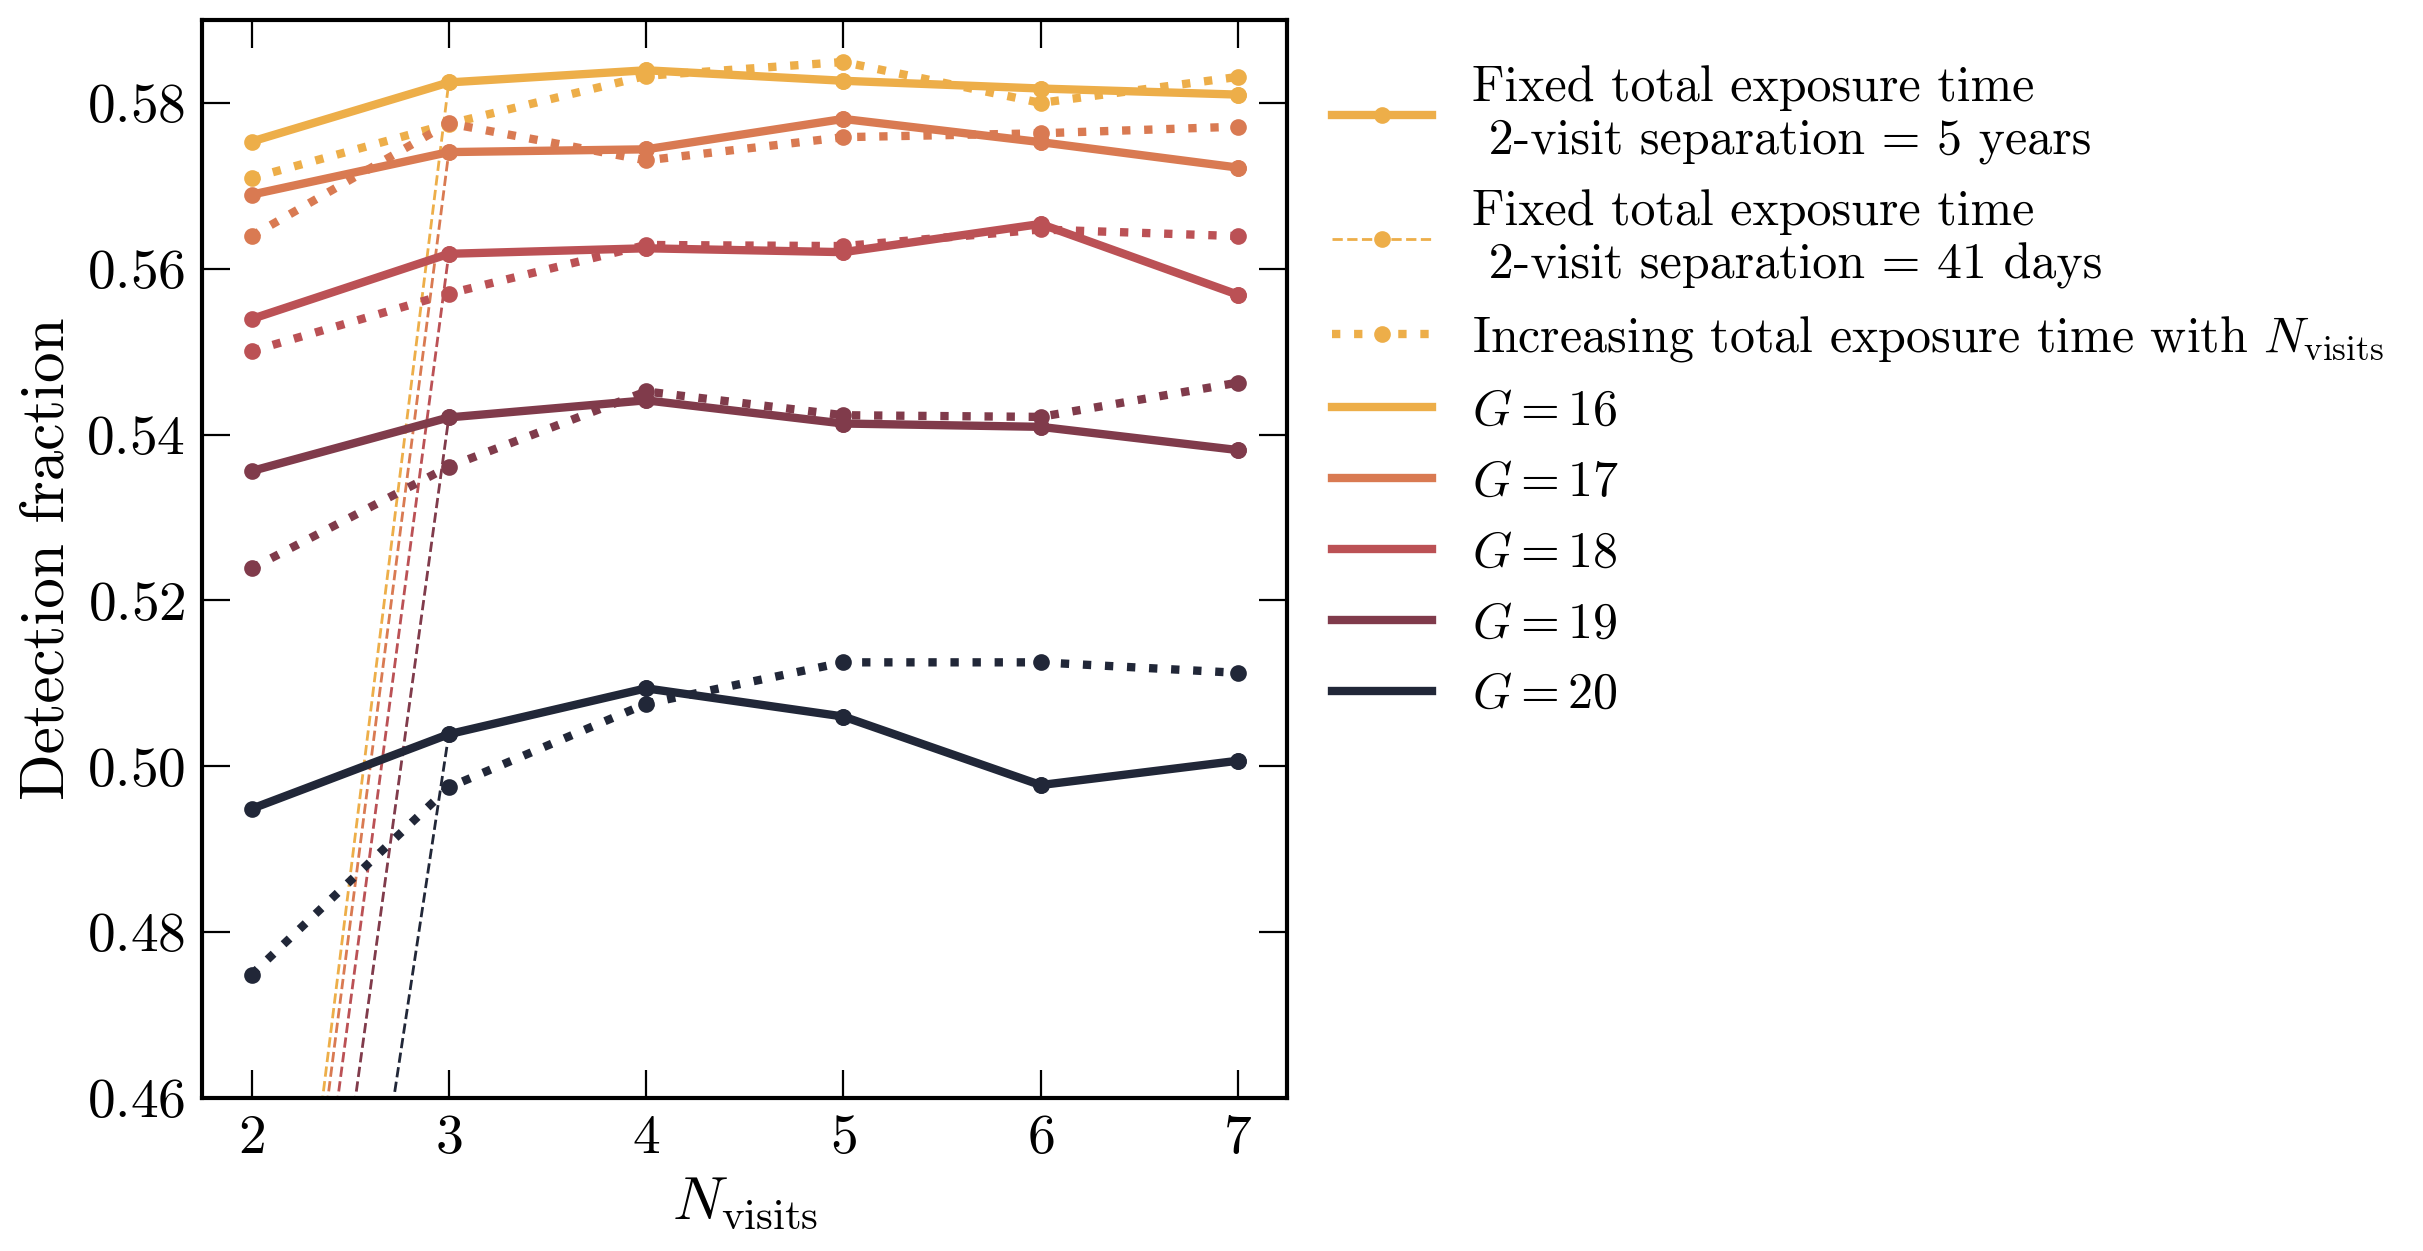

In [70]:
#### make plot. 

fig, ax = plt.subplots()

cc = time_cmap(np.linspace(0, 1, len(Gmags_list)))
for k, G in enumerate(Gmags_list):
    dfs1_this_mag = np.array(dfs_case1[k])
    df2_this_mag = np.array([dfs_case2[k]]) # this should just be a number. 
    dfs2_this_mag = np.concatenate([df2_this_mag, dfs1_this_mag[1:]]) # prepend it to the alternative array
    dfs3_this_mag = np.array(dfs_case3[k])

    ax.plot(nvisits_list, dfs1_this_mag, marker='o', color=cc[k], label="Fixed total exposure time \n 2-visit separation = 5 years" if k==0 else None)
    ax.plot(nvisits_list, dfs2_this_mag, marker='o', color=cc[k], linestyle='--', lw=1, label="Fixed total exposure time \n 2-visit separation = 41 days" if k==0 else None)
    ax.plot(nvisits_list, dfs3_this_mag, marker='o', color=cc[k], linestyle='dotted', label=r"Increasing total exposure time with $N_{\rm visits}$" if k==0 else None)

    ax.plot([2],[0.5], color=cc[k], label=r"$G=%i$"%G)
# ax.set_yscale('log')
# ax.set_xscale('log')
ax.set_xlabel(r'$N_{\rm visits}$')
ax.set_ylabel(r'Detection fraction')
ax.legend(loc='upper left', bbox_to_anchor=[1,1])
ax.set_ylim(0.46, 0.59)
ax.minorticks_off()

# detection fraction as a function of orbital period, mass ratio

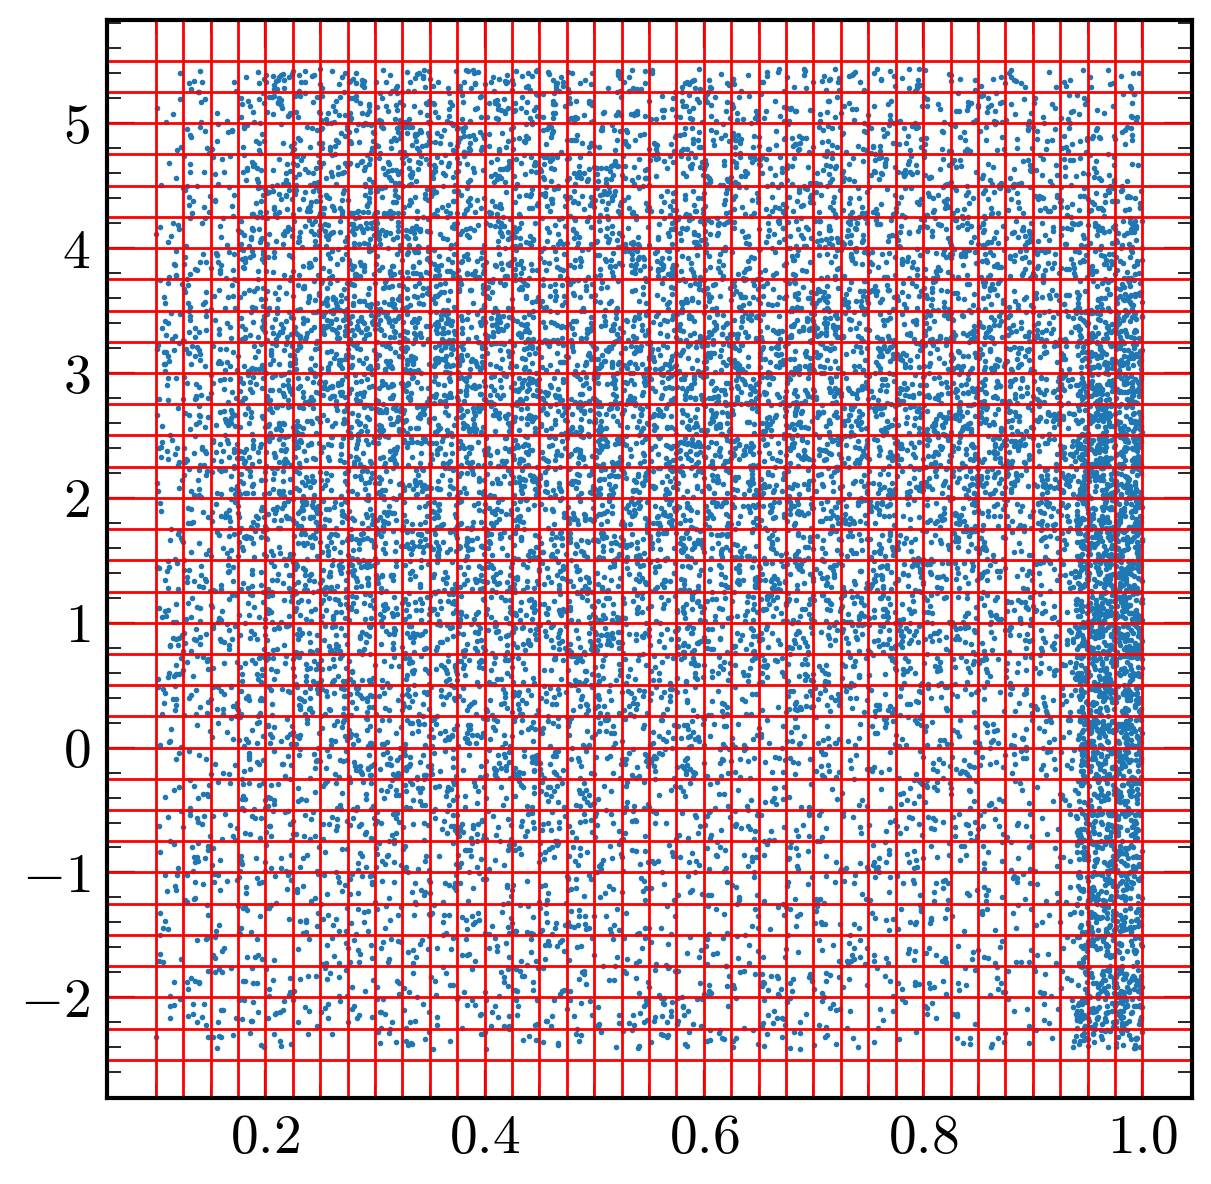

In [73]:
def get_detection_fraction_for_hist2D(rvs_subset):
    if len(rvs_subset) == 0:
        return np.nan
    
    erv = viamock.errors.get_viaspec_errors(
        G=17,
        feh=-2.0,
        logteff=np.log10(4700),
        exptime_ehr=2/len(obstimes[0])
    )[0]

    detected, deltavsys = paf.get_detections(
        erv,                       # km/s
        rvs_subset,                # shape (n_bin, 3)
        v0_vals=np.zeros(len(rvs_subset)) * u.km/u.s,
        bool_arr='detet'
    )
    
    return detected.sum() / len(rvs_subset)
### the observation cadence, exposure time, magnitude will be fixed in this experiment
offset=1
obstimes = np.logspace(np.log10(offset), np.log10(survey_duration_days+offset), 3) - offset
obstimes = np.vstack([obstimes]*N)
rvs = paf.get_rvs(params, obstimes, verbose=False, add_noise=True, noise_level = erv, rng=rng) ### these correspond to params. 

# ### decide on binning: 
logPyr = np.log10(P.to(u.yr).value)

dq = .025
q_bins = np.arange(0.1, 1.0 + dq, dq)
dlogP = 0.25
logP_bins = np.arange(-2.5, 5.5 + dlogP, dlogP)

plt.scatter(q, logPyr, s=1)
for lP in logP_bins:
    plt.axhline(lP, c='r', lw=1)
for qq in q_bins:
    plt.axvline(qq, c='r', lw=1)


# output array: rows = q bins, cols = logP bins
dfs = np.full((len(q_bins)-1, len(logP_bins)-1), np.nan)

# bin index for each system
q_idx = np.digitize(q, q_bins) - 1
logP_idx = np.digitize(logPyr, logP_bins) - 1

# only keep points inside the defined bin ranges
valid = (
    (q_idx >= 0) & (q_idx < len(q_bins)-1) &
    (logP_idx >= 0) & (logP_idx < len(logP_bins)-1)
)

for i in range(len(q_bins)-1):
    for j in range(len(logP_bins)-1):
        mask = valid & (q_idx == i) & (logP_idx == j)
        if np.any(mask):
            dfs[i, j] = get_detection_fraction_for_hist2D(rvs[mask])

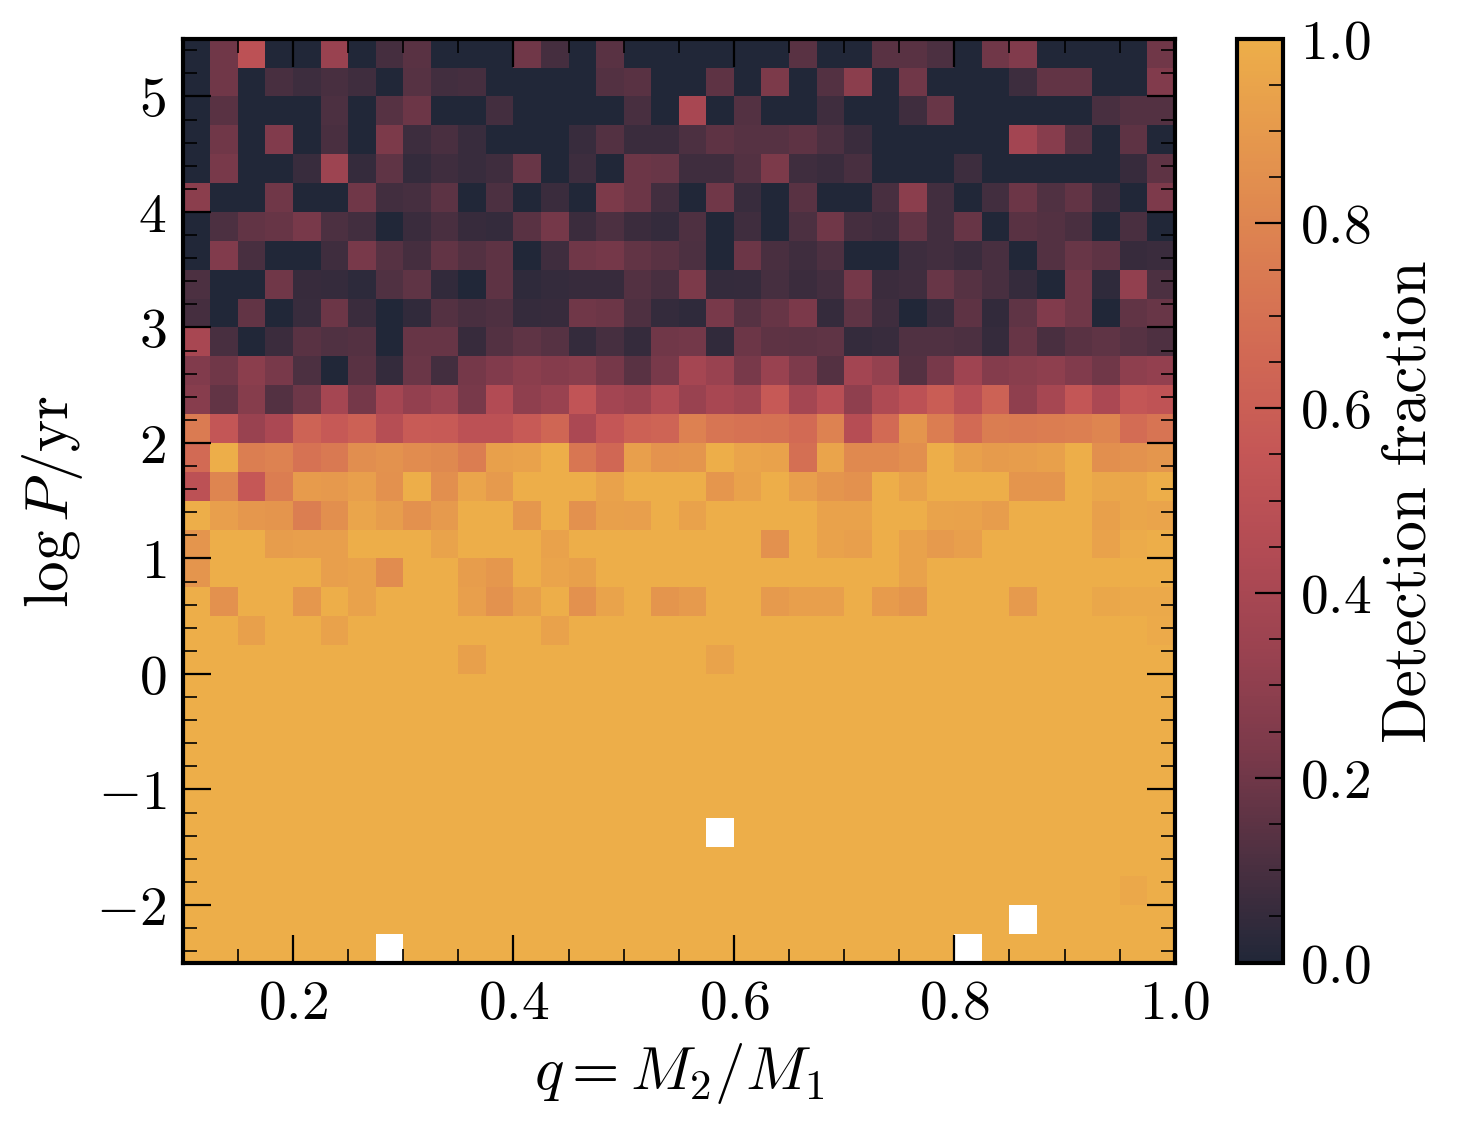

In [81]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(q_bins, logP_bins, dfs.T, #shading='auto', 
               cmap=time_cmap.reversed())
plt.xlabel(r'$q=M_2/M_1$')
plt.ylabel(r'$\log P/\rm{yr}$')
plt.colorbar(label='Detection fraction')
plt.show()